In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib import patches as pat
from matplotlib import transforms
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from joblib import load, dump
import re
import scipy.cluster.hierarchy as sch
from scipy.signal import find_peaks

# custom code
import figutils
sys.path.insert(
    0, os.path.abspath('../2021_07_31_custom_adjacency_regularization/'))
import sequence_logo
from quad_model import *
import kl
import force

from IPython.display import Image
import pygraphviz as pgv

from collections.abc import Iterable
from copy import deepcopy

%matplotlib inline

2022-09-07 11:13:55.415240: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-09-07 11:13:55.415271: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Matplotlib is building the font cache; this may take a moment.


In [3]:
plt.style.use('/home/ms7490/scratch/code/scratch/matplotlib/clean.mplstyle')

# Load data and models

In [4]:
xTr = load(f'../2021_07_31_custom_adjacency_regularization/data/xTr_ES7_HeLa_ABC.pkl')
yTr = load(f'../2021_07_31_custom_adjacency_regularization/data/yTr_ES7_HeLa_ABC.pkl')
xTe = load(f'../2021_07_31_custom_adjacency_regularization/data/xTe_ES7_HeLa_ABC.pkl')
yTe = load(f'../2021_07_31_custom_adjacency_regularization/data/yTe_ES7_HeLa_ABC.pkl')

In [5]:
model_fname = f'../2021_07_31_custom_adjacency_regularization/models/custom_adjacency_regularizer_20210731_124_step3.h5'
model = tf.keras.models.load_model(model_fname)

2022-09-07 11:14:10.483217: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2022-09-07 11:14:10.483260: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: gr017.hpc.nyu.edu
2022-09-07 11:14:10.483264: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: gr017.hpc.nyu.edu
2022-09-07 11:14:10.483383: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: Invalid argument: expected %d.%d, %d.%d.%d, or %d.%d.%d.%d form for driver version; got "1"
2022-09-07 11:14:10.483402: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 510.47.3
2022-09-07 11:14:10.483912: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operation

In [6]:
num_seq_filters = model.get_layer('qc_incl').kernel.shape[2]
num_struct_filters = model.get_layer('c_incl_struct').kernel.shape[2]

position_bias_size = model.get_layer('position_bias_incl').kernel.shape[0]
struct_filter_width = model.get_layer("c_incl_struct").kernel.shape[0]
input_length = model.input[0].shape[1]

# Compute activations

In [7]:
structure_out_model = Model(inputs=model.inputs, outputs=[
    model.get_layer('activation_2').output,
    model.get_layer('activation_3').output
])

In [8]:
# incl_act, skip_act = structure_out_model.predict(xTr, verbose=1, batch_size=4)

In [9]:
def augment_position(seq, pos, alphabet={'A', 'C', 'G', 'U'}):
    remaining_alphabet = alphabet - {seq[pos]}
    out = []
    for e in remaining_alphabet:
        seq_copy = list(str(seq))
        seq_copy[pos] = e
        out.append(''.join(seq_copy))
    return out

In [10]:
def compute_aug_seq_acts(seq, pos, structure_acts_model):
    aug_seqs = augment_position(seq, pos)
    aug_seqs_input = figutils.create_input_data(aug_seqs)
    
    return structure_acts_model.predict(aug_seqs_input).sum(axis=-1)

In [11]:
def compute_aug_seq_acts_batch(seq, structure_acts_model):
    all_augs = [augment_position(seq, pos) for pos, _ in enumerate(seq)]
    all_augs_flat = [e for a in all_augs for e in a]
    all_augs_flat_input = figutils.create_input_data(all_augs_flat)
    struct_preds = structure_acts_model.predict(all_augs_flat_input).sum(axis=-1)
    
    out = []
    ctr = 0
    for e in all_augs:
        out.append(
            struct_preds[ctr:ctr+len(e)]
        )
        ctr += len(e)
    return out

In [12]:
def compute_baseline_act(seq, structure_acts_model):
    return structure_acts_model.predict(figutils.create_input_data([seq])).sum(axis=-1)

In [13]:
def compute_aug_seq_acts_diff(seq, structure_acts_model, pad=False, ignore_higher=False,
                              diff_fn=lambda base, mut: np.abs(base - mut).mean(axis=-1)):
    baseline_act = compute_baseline_act(seq, structure_acts_model)
    
    aug_seq_acts = compute_aug_seq_acts_batch(seq, structure_acts_model)
    
    out = np.stack(aug_seq_acts)
    if ignore_higher:
        out = np.minimum(out, baseline_act)

    out = diff_fn(baseline_act, out)
    
    if not pad:
        return out
    
    return np.pad(out, pad_width=[(0, 5)], mode='constant', constant_values=0)

In [14]:
def print_formatted_sensitivities(sensitivities):
    for e in sensitivities:
        print(np.round(e, decimals=3), end=' ')
    print()

In [15]:
def merge_activations(acts, groups):
    assert len(acts.shape) == 3
    
    out = np.zeros((acts.shape[0], acts.shape[1], len(groups))) + np.nan
    
    ctr = 0
    for g in sorted(groups.keys()):
        out[:, :, ctr] = acts[:, :, groups[g]].sum(axis=2)
        ctr += 1
        
    return out

# Saliency maps for sequence motifs

In [16]:
seq_filters_grouping = load('./data/seq_filters_grouping.pkl')
struct_filters_grouping = load('./data/struct_filters_grouping.pkl')

In [17]:
incl_group_models = {}

D = seq_filters_grouping['incl_membership_dict']
for group_id in D:
    incl_group_models[group_id] = Model(inputs=model.inputs, outputs=[
        sum([model.get_layer('activation_2').output[..., lfi]
             for lfi in D[group_id]])
    ])

In [18]:
skip_group_models = {}

D = seq_filters_grouping['skip_membership_dict']
for group_id in D:
    skip_group_models[group_id] = Model(inputs=model.inputs, outputs=[
        sum([model.get_layer('activation_3').output[..., lfi]
             for lfi in D[group_id]])
    ])

In [19]:
es7_c4 = 'GCGGCACCTACTACAATGTCCCCCGCTGCATACACTCGGAGCCAATAGGGCGCCTATAGAGTGTAGTCCT'

In [20]:
seqs = [figutils.add_flanking(e, 10).replace('T', 'U') for e in [es7_c4]]

---

In [21]:
baseline_act = compute_baseline_act(seqs[0], incl_group_models[1])
    
aug_seq_acts = compute_aug_seq_acts_batch(seqs[0], incl_group_models[1])

2022-09-07 11:14:16.049713: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


In [22]:
out = np.stack(aug_seq_acts)

In [23]:
diff_fn = lambda base, mut: np.maximum(0, (base - mut).mean(axis=-1))

In [24]:
out = diff_fn(baseline_act, out)

---

In [25]:
from tqdm.auto import tqdm

In [26]:
# # generate saliencies
# saliencies = dict()

# for seq in tqdm(seqs):
#     incl_sensitivities = dict()
#     skip_sensitivities = dict()
    
#     for group_id in tqdm(incl_group_models, leave=False):
#         saliency_model = incl_group_models[group_id]
#         sensitivities = compute_aug_seq_acts_diff(seq, saliency_model, diff_fn=diff_fn)
#         incl_sensitivities[group_id] = deepcopy(sensitivities)
    
#     for group_id in tqdm(skip_group_models, leave=False):
#         saliency_model = skip_group_models[group_id]
#         sensitivities = compute_aug_seq_acts_diff(seq, saliency_model, diff_fn=diff_fn)
#         skip_sensitivities[group_id] = deepcopy(sensitivities)
        
#     saliencies[seq] = {
#         'incl':deepcopy(incl_sensitivities),
#         'skip':deepcopy(skip_sensitivities)
#     }

In [27]:
seq = seqs[0]

In [28]:
incl_acts, skip_acts = structure_out_model.predict(figutils.create_input_data([seq]))

In [29]:
def parse_raw_maps(raw_maps):
    out = {'incl':{}, 'skip':{}}
    for line in raw_maps.split('\n'):
        incl_or_skip, key, valm1 = line.split(' ')
        key, valm1 = map(int, [key, valm1])
        val = valm1 + 1
        out[incl_or_skip][key] = val
    return out

In [30]:
raw_maps = """incl 1 0
skip 6 6
incl 3 1
skip 4 7
incl 7 2
skip 3 8
incl 5 3
skip 1 9
incl 6 4
incl 2 5"""
relabel_groups = parse_raw_maps(raw_maps)

In [31]:
sorted_incl_group_ids = np.array(sorted(list(seq_filters_grouping['incl_membership_dict'].keys())))[
    np.argsort(merge_activations(incl_acts, seq_filters_grouping['incl_membership_dict']).sum(axis=(0, 1)))[::-1]]

In [32]:
# plt.figure(figsize=(20, 2))
# baseline = sum([saliencies[seq]['incl'][key] for key in sorted_incl_group_ids[::-1]])

# for idx, b in enumerate(baseline):
#     if idx > 0 and idx % 10 == 0:
#         plt.text(idx, -2.5, f'{idx}', ha='center', va='center')

# for key in sorted_incl_group_ids[:3]:
#     baseline -= saliencies[seq]['incl'][key]
#     plt.bar(range(90), saliencies[seq]['incl'][key], bottom=baseline, label=relabel_groups['incl'][key])

# if any(np.abs(baseline) > 1e-5):
#     plt.bar(range(90), baseline, label='other')
    
# plt.xticks(range(90), list(seq))
# plt.xlim(0,89)

# xticklabels = plt.gca().get_xticklabels()
# tick_colors = ['#6c757d']*10 + ['k']*70 + ['#6c757d']*10
# for ticklabel, tickcolor in zip(xticklabels, tick_colors):
#     ticklabel.set_color(tickcolor)
    
# plt.legend(frameon=False)

In [33]:
def shift_row(row, shift=0, total_len=90):
    out = np.zeros(total_len)
    
    offset = (total_len - len(row)) // 2
    
    out[offset+shift:offset+len(row)+shift] += row
    return out

In [34]:
tmp_incl_shifts = """0 2
19 1
7 1
1 1
2 0
13 2
12 0
10 2
15 2
3 3
8 0
5 1
16 0
4 2
17 2
6 0
11 1
9 1
14 0
18 1"""
incl_shifts = [[int(e) for e in r.split(' ')]
               for r in tmp_incl_shifts.split('\n')]
incl_shifts = [b for a, b in sorted(incl_shifts, key=lambda x: x[0])]

In [35]:
tmp_skip_shifts = """0 1
17 3
5 0
19 1
1 0
9 0
2 2
13 1
8 0
4 3
14 1
15 2
3 2
10 0
18 0
7 1
6 1
12 0
11 0
16 0"""
skip_shifts = [[int(e) for e in r.split(' ')]
               for r in tmp_skip_shifts.split('\n')]
skip_shifts = [b for a, b in sorted(skip_shifts, key=lambda x: x[0])]

In [36]:
shifted_incl_acts = np.array([shift_row(row, row_shift) for row, row_shift in zip(
    incl_acts[0][:, :num_seq_filters].T, incl_shifts)]).T

shifted_skip_acts = np.array([shift_row(row, row_shift) for row, row_shift in zip(
    skip_acts[0][:, :num_seq_filters].T, skip_shifts)]).T

In [37]:
shifted_struct_acts = np.array([
    shift_row(row, 0) for row in skip_acts[0][:, num_seq_filters:].T
]).T

In [38]:
# plt.figure(figsize=(20, 2))

# D = seq_filters_grouping['incl_membership_dict']
# baseline = 0


# for key in relabel_groups['incl'].keys():
#     row = shifted_incl_acts[:, D[key]].sum(axis=1)
#     plt.bar(range(90), row, bottom=baseline, label=f"Group {relabel_groups['incl'][key]}")
#     baseline += row
# plt.legend()

# plt.xticks(range(90), list(seq))
# plt.xlim(0, 89)

In [39]:
porg_key = 1
loop_key = 2

In [40]:
light_incl_color = '#C5D6FB'
light_skip_color = '#F6C3C2'
edgecolor = '#868686'

In [41]:
label_helper = lambda x: '' if len(x) > 1 else x

/state/partition1/job-24569557/ipykernel_508467/3302115491.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  axarr[1].set_yticklabels([int(abs(tick)) for tick in ticks])


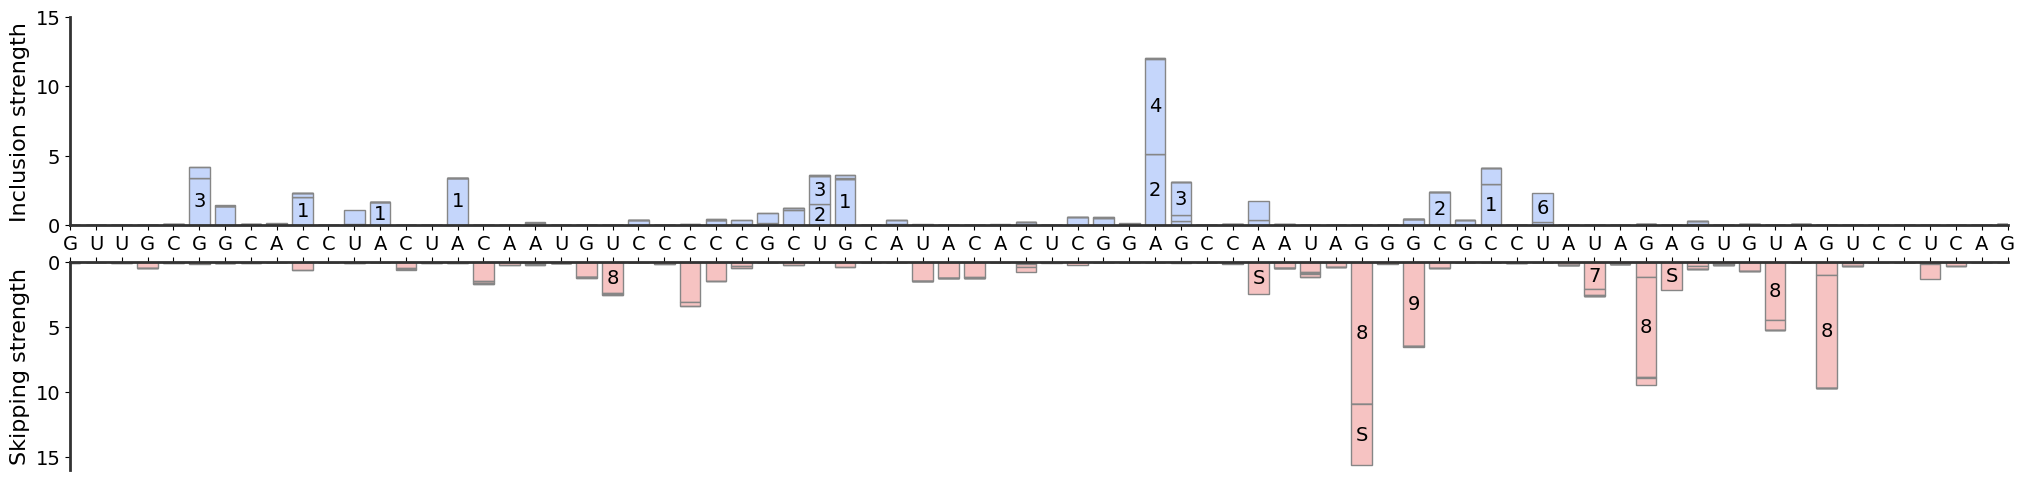

In [43]:
# credit for generated colors: http://vrl.cs.brown.edu/color
colors = ["1b46b8","b6175b","f1d01a","6cb236","e9e8e5","f75408","ead47c","4dab80","f68d12", '8701b1', 'd1ea2c']
colors = [f'#{c}' for c in colors]
num_colors = len(colors)
color_idx = 0

fig, axarr = plt.subplots(2, 1, figsize=(25, 6), dpi=100)
axarr[0].set_xticks(range(90))
axarr[0].set_xticklabels(list(seq))
axarr[0].set_xlim(0, 89)


min_bar_height_for_label = 1.5
baseline = 0
for key in relabel_groups['incl'].keys():
    row = shifted_incl_acts[:, seq_filters_grouping['incl_membership_dict'][key]].sum(axis=1)
    label = label_helper(f"{relabel_groups['incl'][key]}")
    container = axarr[0].bar(range(90), row, bottom=baseline,
                 label=label, color=light_incl_color, edgecolor=edgecolor)
#                              color=colors[color_idx % num_colors])
    color_idx += 1
    baseline += row
    container_labels = ['' if i not in np.where(row > min_bar_height_for_label)[0] else label for i in range(90)]
    axarr[0].bar_label(container, labels=container_labels, label_type='center')

baseline = 0

for key in relabel_groups['skip']:
    row = shifted_skip_acts[:, seq_filters_grouping['skip_membership_dict'][key]].sum(axis=1)
    label= label_helper(f"{relabel_groups['skip'][key]}")
    container = axarr[1].bar(range(90), -row, bottom=baseline,
                 label=label, color=light_skip_color, edgecolor=edgecolor)
#                              color=colors[color_idx % num_colors])
    color_idx += 1
    baseline -= row
    container_labels = ['' if i not in np.where(row > min_bar_height_for_label)[0] else label for i in range(90)]
    axarr[1].bar_label(container, labels=container_labels, label_type='center')
    
for key, label in zip([porg_key, loop_key], ['P', 'S']):
    row = shifted_struct_acts[:, struct_filters_grouping['skip_membership_dict'][key]].sum(axis=1)
    container = axarr[1].bar(range(90), -row, bottom=baseline, label=label, color=light_skip_color, edgecolor=edgecolor)
#                  color=colors[color_idx % num_colors])
    color_idx += 1
    baseline -= row
    container_labels = ['' if i not in np.where(row > min_bar_height_for_label)[0] else label_helper(label) for i in range(90)]
    axarr[1].bar_label(container, labels=container_labels, label_type='center')


axarr[1].spines.bottom.set_visible(False)
axarr[1].spines.top.set_visible(True)
axarr[1].xaxis.tick_top()
axarr[1].set_xticks(range(90))
axarr[1].set_xticklabels([])

xticklabels = axarr[0].get_xticklabels()
tick_colors = ['#6c757d']*7 + ['k']*76 + ['#6c757d']*7
for ticklabel, tickcolor in zip(xticklabels, tick_colors):
    ticklabel.set_color(tickcolor)

axarr[0].set_ylim(0, 15)
axarr[1].set_ylim(-16, 0)
axarr[0].set_xlim(7, 90-8)
axarr[1].set_xlim(7, 90-8)

ticks = axarr[1].get_yticks()
axarr[1].set_yticklabels([int(abs(tick)) for tick in ticks])

axarr[0].set_ylabel('Inclusion strength', fontsize=16)
axarr[1].set_ylabel('Skipping strength', fontsize=16)

# leg = axarr[0].legend()
# frame = leg.get_frame()
# frame.set_linewidth(1.5)
# leg = axarr[1].legend()
# frame = leg.get_frame()
# frame.set_linewidth(1.5)

fig.subplots_adjust(hspace=0.175)
fig.savefig('./figs/activation_saliency.png',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/activation_saliency.svg',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')
plt.show()

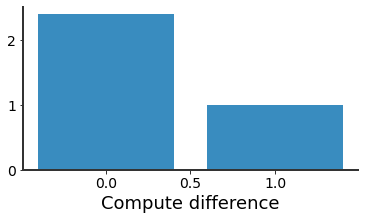

In [51]:
plt.figure(figsize=(6, 3))
plt.bar([0, 1], [2.4, 1])
plt.xlabel('Compute difference')
plt.savefig('./figs/text.svg', transparent=True, pad_inches=0.1,
    bbox_inches='tight')

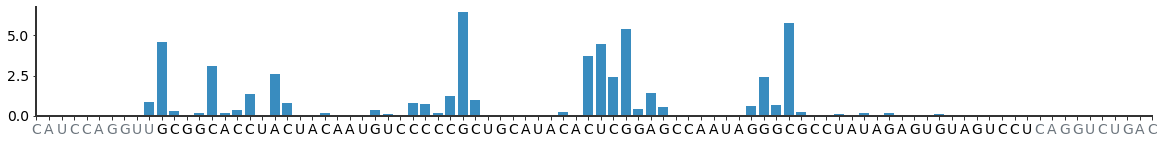

In [49]:
plt.figure(figsize=(20, 2))
plt.bar(range(85), incl_acts.sum(axis=(0, 2)))

plt.xticks(range(90), list(seq))
plt.xlim(0,89)

xticklabels = plt.gca().get_xticklabels()
tick_colors = ['#6c757d']*10 + ['k']*70 + ['#6c757d']*10
for ticklabel, tickcolor in zip(xticklabels, tick_colors):
    ticklabel.set_color(tickcolor)

In [34]:
sorted_skip_group_ids = np.array(sorted(list(seq_filters_grouping['skip_membership_dict'].keys())))[
    np.argsort(merge_activations(skip_acts, seq_filters_grouping['skip_membership_dict']).sum(axis=(0, 1)))[::-1]]

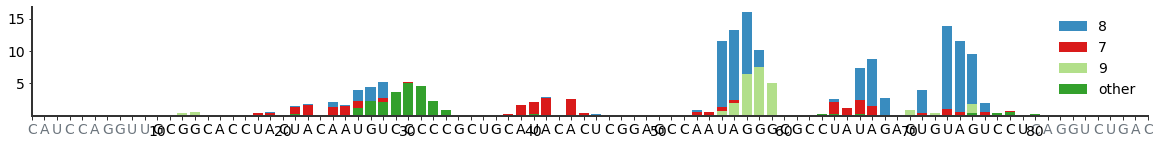

In [35]:
plt.figure(figsize=(20, 2))
baseline = sum([saliencies[seq]['skip'][key] for key in sorted_skip_group_ids[::-1]])

for idx, b in enumerate(baseline):
    if idx > 0 and idx % 10 == 0:
        plt.text(idx, -2.5, f'{idx}', ha='center', va='center')

for key in sorted_skip_group_ids[:3]:
    baseline -= saliencies[seq]['skip'][key]
    if key in relabel_groups['skip']:
        label = relabel_groups['skip'][key]
    else:
        label = ''
    plt.bar(range(90), saliencies[seq]['skip'][key], bottom=baseline, label=label)

if any(np.abs(baseline) > 1e-5):
    plt.bar(range(90), baseline, label='other')
    
plt.xticks(range(90), list(seq))
plt.xlim(0,89)

xticklabels = plt.gca().get_xticklabels()
tick_colors = ['#6c757d']*10 + ['k']*70 + ['#6c757d']*10
for ticklabel, tickcolor in zip(xticklabels, tick_colors):
    ticklabel.set_color(tickcolor)
    
plt.legend(frameon=False)

In [ ]:
plt.figure(figsize=(20, 2))
baseline = sum([saliencies[seq]['skip'][key] for key in sorted_skip_group_ids[::-1]]) # np.zeros(90)
for key in sorted_skip_group_ids[:4]:
    baseline -= saliencies[seq]['skip'][key]
    plt.bar(range(90), saliencies[seq]['skip'][key], bottom=baseline, label=key)

    
if any(np.abs(baseline) > 1e-5):
    plt.bar(range(90), baseline, label='other')
    
plt.xticks(range(90), list(seq))
plt.xlim(0,89)
plt.legend()

In [ ]:
print_formatted_sensitivities(saliencies[seq]['incl'][7])

---------------

In [ ]:
def make_struct_graph(seq):
    _, a, _ = figutils.compute_structure([seq])
    nodes = [i for i, _ in enumerate(seq)]
    stack = []
    edges = []
    for i, nt in enumerate(a[0]):
        if i != 0:
            edges.append((i-1, i))
        if nt == '.':
            continue
        elif nt == '(':
            stack.append(i)
        elif nt == ')':
            assert len(stack) > 0
            left = stack[-1]
            right = i
            stack = stack[:-1]
            edges.append((left, right))
    assert len(stack) == 0
    
    return nodes, edges

In [ ]:
def draw(dot):
    return Image(dot)

In [ ]:
A = pgv.AGraph()
# add some edges
A.add_edge(1, 2)
A.add_edge(2, 3)
A.add_edge(1, 3)
A.add_edge(3, 4)
A.add_edge(3, 5)
A.add_edge(3, 6)
A.add_edge(4, 6)
# make a subgraph with rank='same'
B = A.add_subgraph([4, 5, 6], name="s1", rank="same")
B.graph_attr["rank"] = "same"
# print(A.string())  # print dot file to standard output
draw(A.draw(format='png', prog="neato"))

In [ ]:
nodes, edges = make_struct_graph(seq)

In [ ]:
A = pgv.AGraph(strict=True, overlap=False, splines='false')
for left, right in edges:
    A.add_edge(left, right)
draw(A.draw(format='png', prog='neato'))

In [ ]:
npad = ((0, 0), (2, 3), (0, 0))

In [ ]:
for row in np.pad(
    skip_act[single_peak_selector * peak_found][median_act_results['idx']],
    pad_width=npad, mode='constant', constant_values=0
):
    for e in row[:, loop_filters].sum(axis=1):
        print(np.round(e, decimals=3), end=' ')
    print()
    print()

In [ ]:
input_example = figutils.create_input_data([median_act_results['seq'].iloc[0]])

In [ ]:
plt.plot(structure_acts_model.predict(input_example)[0])

In [ ]:
xTr_concat = np.concatenate(xTr, axis=-1)

In [ ]:
c_skip_struct = structure_out_model.get_layer('c_skip_struct')

In [ ]:
xTr_subset_expanded = tf.expand_dims(xTr_concat[single_peak_selector * peak_found][median_act_results['idx'].values], axis=(2,))

In [ ]:
xTr_subset_expanded.shape

In [ ]:
xTr_single_peak_patches = tf.image.extract_patches(xTr_subset_expanded,
                sizes=[1, c_skip_struct.kernel_size[0], 1, 1],
                strides=[1, 1, 1, 1],
                rates=[1, 1, 1, 1],
                padding='SAME')

In [ ]:
xTr_single_peak_patches_squeezed = tf.squeeze(xTr_single_peak_patches, axis=2)

In [ ]:
xTr_single_peak_patches_squeezed

In [ ]:
xTr_concat.shape

In [ ]:
for e in median_act_results['seq'].values:
    print(e)

In [ ]:
peak_hints

In [ ]:
results

In [ ]:
idx = 3

In [ ]:
left, right = localized_loops[idx]
left, right

In [ ]:
padding = 0

In [ ]:
figutils.oh_2_str(xTr[0][single_peak_selector * peak_found][idx], kind='seq')

In [ ]:
xTr_subset_nt[idx]

In [ ]:
xTr_subset_nt[idx][int(left[0])-padding:int(right[-1])+1+padding]

In [ ]:
plt.plot(skip_act[single_peak_selector * peak_found][idx][:, num_seq_filters + loop_filters], label=['med', 'long', 'short'])
plt.legend()

In [ ]:
figutils.oh_2_str(xTr[0][single_peak_selector * peak_found][idx], kind='seq')

In [ ]:
x_seq = xTr[0][single_peak_selector * peak_found][idx:idx+1]
x_struct = xTr[1][single_peak_selector * peak_found][idx:idx+1]
x_wobble = xTr[2][single_peak_selector * peak_found][idx:idx+1]

In [ ]:
x_struct[:, 63:90] = np.zeros_like(x_struct[:, 63:90])
x_struct[:, 63:90, 0] = 1

In [ ]:
_, B = structure_out_model.predict([x_seq, x_struct, x_wobble])

In [ ]:
plt.plot(B[0][:, num_seq_filters + loop_filters], label=['med', 'long', 'short'])
plt.legend()

In [ ]:
structure_out_model.summary()